In [96]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
from scipy.ndimage import label as scipy_label
from scipy.spatial import KDTree
import skimage as ski
from PIL import Image
import cv2
from skimage.filters import sato
from skan import Skeleton, summarize
from skan.csr import skeleton_to_nx
from skimage import morphology
from skimage.measure import label, regionprops
import networkx as nx
import pandas as pd
import pickle
from pathlib import Path

In [97]:
IMAGE_ID = 'S1585-2_b'
BASE_PATH = f"/home/pony/projects/ienf_q/data_0320/{IMAGE_ID}"

SEGMENT_LENGTH = 3
SEARCH_RADIUS = 50
PATH_FINDING_BBOX_PADDING = 10

OUTPUT_DIR = Path('../data/datasets')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Image: {IMAGE_ID}")
print(f"segment_length={SEGMENT_LENGTH}, search_radius={SEARCH_RADIUS}")
print(f"Output: {OUTPUT_DIR}")

Image: S1585-2_b
segment_length=3, search_radius=50
Output: ../data/datasets


Original Image: (1946, 5632)
Annotation: (1946, 5632)
GT Label: (1946, 5632)


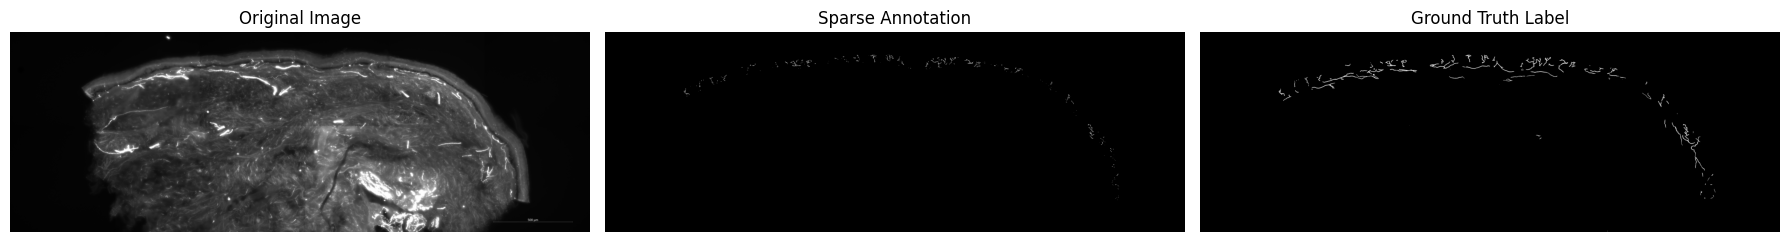

In [98]:
orig_img = cv2.imread(f"{BASE_PATH}/image.png", cv2.IMREAD_COLOR_RGB)
orig_img = np.array(orig_img)[:,:,1]  # 只保留綠色通道
annotation_img = cv2.imread(f"{BASE_PATH}/annotation.png", cv2.IMREAD_GRAYSCALE)
label_img = cv2.imread(f"{BASE_PATH}/label.png", cv2.IMREAD_GRAYSCALE)

print(f"Original Image: {orig_img.shape}")
print(f"Annotation: {annotation_img.shape}")
print(f"GT Label: {label_img.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(orig_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(annotation_img, cmap='gray')
axes[1].set_title('Sparse Annotation')
axes[1].axis('off')
axes[2].imshow(label_img, cmap='gray')
axes[2].set_title('Ground Truth Label')
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [99]:
# 5.1 骨架化
binary = (annotation_img > 0).astype(np.uint8)
skeleton = morphology.skeletonize(binary).astype(np.uint8)
skel_obj = Skeleton(skeleton, keep_images=False)
summary = summarize(skel_obj)
skeleton_graph = skeleton_to_nx(skel_obj, summary=summary)

print(f"Skeleton nodes: {skeleton_graph.number_of_nodes()}")
print(f"Skeleton edges: {skeleton_graph.number_of_edges()}")

Skeleton nodes: 962
Skeleton edges: 518


/tmp/ipykernel_205572/3132388155.py:5: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [100]:
# 5.2 過濾短邊
filtered_skeleton_graph = nx.MultiGraph()
for u, v, data in skeleton_graph.edges(data=True):
    path = data['path']
    if len(path) > 2 or (skeleton_graph.degree(u) != 1 and skeleton_graph.degree(v) != 1):
        filtered_skeleton_graph.add_edge(u, v, **data)

mapping = {i: tuple(skel_obj.coordinates[i].astype(int)) for i in filtered_skeleton_graph.nodes()}
filtered_skeleton_graph = nx.relabel_nodes(filtered_skeleton_graph, mapping)

print(f"Filtered nodes: {filtered_skeleton_graph.number_of_nodes()}")
print(f"Filtered edges: {filtered_skeleton_graph.number_of_edges()}")

Filtered nodes: 648
Filtered edges: 356


In [101]:
# 5.3 合併中間點
middle_points = [point for point in filtered_skeleton_graph.nodes() if len(list(filtered_skeleton_graph.neighbors(point))) == 2]

for mp in middle_points:
    neighbors = list(filtered_skeleton_graph.neighbors(mp))
    if len(neighbors) != 2:
        continue
    u, v = neighbors
    path1 = filtered_skeleton_graph[u][mp][0]['path']
    path2 = filtered_skeleton_graph[mp][v][0]['path']
    u_y, u_x = u
    mp_y, mp_x = mp
    v_y, v_x = v

    result_path = []
    if tuple(path1[-1]) == (mp_y, mp_x) and tuple(path1[0]) == (u_y, u_x):
        result_path.extend(path1)
    else:
        result_path.extend(path1[::-1])
    
    if tuple(path2[0]) == (mp_y, mp_x) and tuple(path2[-1]) == (v_y, v_x):
        result_path.extend(path2[1:])
    else:
        result_path.extend(path2[-2::-1])
    
    filtered_skeleton_graph.remove_node(mp)
    filtered_skeleton_graph.add_edge(u, v, path=result_path)

print(f"After merge nodes: {filtered_skeleton_graph.number_of_nodes()}")
print(f"After merge edges: {filtered_skeleton_graph.number_of_edges()}")

After merge nodes: 632
After merge edges: 336


In [102]:
# 5.4 補齊缺失的節點
label_img_components = label(binary, connectivity=2)
regions = regionprops(label_img_components)

for region in regions:
    min_row, min_col, max_row, max_col = region.bbox
    bbox_nodes = [node for node in filtered_skeleton_graph.nodes() 
                  if node[0] >= min_row and node[0] < max_row and node[1] >= min_col and node[1] < max_col]
    if len(bbox_nodes) != 0:
        continue
    
    brightest_pixel = None
    brightest_value = -1
    for r in range(min_row, max_row):
        for c in range(min_col, max_col):
            if orig_img[r, c] > brightest_value:
                brightest_value = orig_img[r, c]
                brightest_pixel = (r, c)
    filtered_skeleton_graph.add_node(brightest_pixel)

print(f"Nodes after fill: {filtered_skeleton_graph.number_of_nodes()}")

Nodes after fill: 833


In [103]:
# 5.5 生成種子圖
seed_graph = nx.MultiGraph()
segment_length = SEGMENT_LENGTH

for u in filtered_skeleton_graph.nodes():
    seed_graph.add_node(u)

for u, v, data in filtered_skeleton_graph.edges(data=True):
    path = data['path']
    corrected_path = path[:] if tuple(path[0]) == u and tuple(path[-1]) == v else path[::-1]
    path_arr = np.array(corrected_path)
    diffs = np.diff(path_arr, axis=0)
    distances = np.linalg.norm(diffs, axis=1)
    cumulative_distances = np.concatenate(([0], np.cumsum(distances)))
    path_length = cumulative_distances[-1]
    num_segments = int(path_length // segment_length)
    
    if num_segments <= 0:
        seed_graph.add_edge(u, v, path=path)
        continue
    
    last_index = 0
    for i in range(num_segments):
        target_distance = (i + 1) * path_length / num_segments
        segment_end_index = 0
        for idx, cumulative_distance in enumerate(cumulative_distances[last_index:]):
            if cumulative_distance >= target_distance:
                segment_end_index = idx + last_index
                break
        segment_path = corrected_path[last_index:segment_end_index + 1]
        if len(segment_path) == 0:
            continue
        seed_graph.add_edge(tuple(segment_path[0]), tuple(segment_path[-1]), path=segment_path)
        last_index = segment_end_index
    
    if last_index < len(corrected_path) - 1:
        final_segment_path = corrected_path[last_index:]
        seed_graph.add_edge(tuple(final_segment_path[0]), tuple(final_segment_path[-1]), path=final_segment_path)

print(f"Seed graph nodes: {seed_graph.number_of_nodes()}")
print(f"Seed graph edges: {seed_graph.number_of_edges()}")

Seed graph nodes: 1101
Seed graph edges: 604


In [104]:
# 可視化種子圖
viz_img = cv2.cvtColor(orig_img.copy(), cv2.COLOR_GRAY2BGR)
viz_img = cv2.addWeighted(viz_img, 0.7, cv2.cvtColor(label_img, cv2.COLOR_GRAY2BGR), 0.3, 0)

for u, v, data in seed_graph.edges(data=True):
    for y_i, x_i in data['path']:
        viz_img[y_i, x_i] = [0, 255, 0]

for u in seed_graph.nodes():
    viz_img[u] = [255, 0, 0]

# plt.figure(figsize=(128, 128))
# plt.imshow(viz_img)
# plt.title('Seed map (green=paths, red=seed points)')
# plt.axis('off')
# plt.show()
cv2.imwrite(str(OUTPUT_DIR / f"dataset_{IMAGE_ID}_seed_viz.png"), cv2.cvtColor(viz_img, cv2.COLOR_RGB2BGR))

True

In [105]:
# Build KDTree from GT pixels for Hausdorff distance computation
gt_pixels = np.column_stack(np.where(label_img > 0))  # (N, 2), each row is (y, x)
gt_kdtree = KDTree(gt_pixels)
print(f"GT pixels: {len(gt_pixels)}, KDTree built")

GT pixels: 48196, KDTree built


In [106]:
# 建立 topology KDTree 和成本地圖
topology_points = np.array(list(seed_graph.nodes()))
kdtree = KDTree(topology_points)

cost_map = ((255 - orig_img.astype(np.float64)) / 255.0) ** 8
cost_map_h, cost_map_w = cost_map.shape

seed_map = np.zeros_like(cost_map, dtype=np.uint8)
for p in topology_points:
    seed_map[p[0], p[1]] = True

print(f"Seed points: {len(topology_points)}")
print(f"Cost map shape: {cost_map.shape}")

Seed points: 1101
Cost map shape: (1946, 5632)


In [107]:
def compute_path_hausdorff_sum(path, gt_kdtree):
    """
    Compute sum of distances from each path point to the nearest GT pixel.
    Higher path length = larger sum, so this naturally penalizes longer paths
    that stray from GT tissue.
    """
    path_pts = np.array(path)
    dists, _ = gt_kdtree.query(path_pts)
    return float(np.sum(dists))

print("Function defined")

Function defined


In [114]:
# A* 路徑查找與樣本收集
all_samples = []
sample_id = 0

annotation_components = label(binary, connectivity=2)
label_binary = (label_img > 0)

for u_idx in range(len(topology_points)):
    u = topology_points[u_idx]
    
    neighbor_indices = kdtree.query_ball_point(u, r=SEARCH_RADIUS)
    targets = [topology_points[v_idx] for v_idx in neighbor_indices]
    targets = [target for target in targets if tuple(target) != tuple(u)]
    
    current_component_id = annotation_components[u[0], u[1]]
    targets = [target for target in targets 
               if annotation_components[target[0], target[1]] != current_component_id]
    
    if len(targets) == 0:
        continue
    
    all_points = [u] + targets
    all_y = [p[0] for p in all_points]
    all_x = [p[1] for p in all_points]
    
    min_y = max(0, min(all_y) - PATH_FINDING_BBOX_PADDING)
    max_y = min(cost_map_h - 1, max(all_y) + PATH_FINDING_BBOX_PADDING)
    min_x = max(0, min(all_x) - PATH_FINDING_BBOX_PADDING)
    max_x = min(cost_map_w - 1, max(all_x) + PATH_FINDING_BBOX_PADDING)
    
    cropped_cost_map = cost_map[min_y : max_y + 1, min_x : max_x + 1]
    local_points = [(pos_global[0] - min_y, pos_global[1] - min_x) for pos_global in all_points]
    mcp = ski.graph.MCP_Geometric(cropped_cost_map, fully_connected=True)
    cumulative_costs, traceback = mcp.find_costs(starts=local_points[:1], ends=local_points[1:])
    
    for target in local_points[1:]:
        if np.isinf(cumulative_costs[target]):
            continue
        
        path = mcp.traceback(target)
        cost = cumulative_costs[target]
        
        global_path = [(p[0] + min_y, p[1] + min_x) for p in path]
        global_start = (u[0], u[1])
        global_target = (target[0] + min_y, target[1] + min_x)
        
        middle_pts = np.array(path[1:-1])
        if len(middle_pts) > 0:
            middle_pts_global = middle_pts + np.array([min_y, min_x])
            if np.any(seed_map[middle_pts_global[:, 0], middle_pts_global[:, 1]]):
                continue
        
        distance = np.linalg.norm(np.array(global_start) - np.array(global_target))
        path_length = len(global_path)
        normalized_cost = cost / path_length if path_length > 0 else cost
        
        # 若路徑未完全在 GT label 中，hausdorff_sum 設為 inf
        path_pts = np.array(global_path)
        path_in_label = label_binary[path_pts[:, 0], path_pts[:, 1]]
        hausdorff_sum = compute_path_hausdorff_sum(global_path, gt_kdtree)
        if not np.all(path_in_label) and hausdorff_sum > 5:  # 設定一個合理的閾值來過濾明顯不合理的路徑
            hausdorff_sum = 10**10
            
        
        all_samples.append({
            'sample_id': sample_id,
            'image_id': IMAGE_ID,
            'seed1_y': global_start[0],
            'seed1_x': global_start[1],
            'seed2_y': global_target[0],
            'seed2_x': global_target[1],
            'distance': distance,
            'path_length': path_length,
            'path_cost': cost,
            'normalized_cost': normalized_cost,
            'hausdorff_sum': hausdorff_sum,
            'path': global_path
        })
        sample_id += 1
    
    if (u_idx + 1) % 100 == 0:
        print(f"Processed {u_idx + 1}/{len(topology_points)} seeds, collected {len(all_samples)} samples")

print(f"\nTotal samples: {len(all_samples)}")

Processed 100/1101 seeds, collected 602 samples
Processed 200/1101 seeds, collected 1138 samples
Processed 300/1101 seeds, collected 1804 samples
Processed 400/1101 seeds, collected 2236 samples
Processed 500/1101 seeds, collected 2617 samples
Processed 600/1101 seeds, collected 3097 samples
Processed 700/1101 seeds, collected 3762 samples
Processed 800/1101 seeds, collected 4309 samples
Processed 900/1101 seeds, collected 4796 samples
Processed 1000/1101 seeds, collected 5203 samples
Processed 1100/1101 seeds, collected 5528 samples

Total samples: 5534


In [115]:
hausdorff_values = [s['hausdorff_sum'] for s in all_samples]
print(f"Total samples: {len(all_samples)}")
print(f"Hausdorff sum - mean: {np.mean(hausdorff_values):.2f}, median: {np.median(hausdorff_values):.2f}, "
      f"min: {np.min(hausdorff_values):.2f}, max: {np.max(hausdorff_values):.2f}")

Total samples: 5534
Hausdorff sum - mean: 5585471630.24, median: 10000000000.00, min: 0.00, max: 10000000000.00


In [116]:
csv_data = [{k: v for k, v in sample.items() if k != 'path'} for sample in all_samples]
df = pd.DataFrame(csv_data)

csv_path = OUTPUT_DIR / f"dataset_{IMAGE_ID}.csv"
df.to_csv(csv_path, index=False)
print(f"CSV saved: {csv_path}")
print(f"Columns: {list(df.columns)}")
display(df.head())

CSV saved: ../data/datasets/dataset_S1585-2_b.csv
Columns: ['sample_id', 'image_id', 'seed1_y', 'seed1_x', 'seed2_y', 'seed2_x', 'distance', 'path_length', 'path_cost', 'normalized_cost', 'hausdorff_sum']


,sample_id,image_id,seed1_y,seed1_x,seed2_y,seed2_x,distance,path_length,path_cost,normalized_cost,hausdorff_sum
0,0,S1585-2_b,232,2619,234,2615,4.472136,6,0.212870,0.035478,0.0
1,1,S1585-2_b,234,2620,234,2615,5.000000,6,0.205584,0.034264,0.0
2,2,S1585-2_b,234,2620,238,2622,4.472136,5,0.208474,0.041695,0.0
3,3,S1585-2_b,234,2620,241,2630,12.206556,13,0.586622,0.045125,0.0
4,4,S1585-2_b,234,2620,238,2620,4.000000,5,0.166465,0.033293,0.0


In [117]:
paths_dict = {sample['sample_id']: sample['path'] for sample in all_samples}
pickle_path = OUTPUT_DIR / f"dataset_{IMAGE_ID}_paths.pkl"

with open(pickle_path, 'wb') as f:
    pickle.dump(paths_dict, f)

print(f"Paths saved: {pickle_path}")
print(f"Total paths: {len(paths_dict)}")

Paths saved: ../data/datasets/dataset_S1585-2_b_paths.pkl
Total paths: 5534


In [118]:
print("="*60)
print("Dataset Statistics")
print("="*60)
print(f"\nTotal samples: {len(df)}")
print(f"\nFeature statistics:")
print(df[['distance', 'path_length', 'normalized_cost', 'hausdorff_sum']].describe())

Dataset Statistics

Total samples: 5534

Feature statistics:
          distance  path_length  normalized_cost  hausdorff_sum
count  5534.000000  5534.000000      5534.000000   5.534000e+03
mean     18.764564    20.458077         0.037843   5.585472e+09
std      12.221697    14.269639         0.031888   4.966053e+09
min       2.000000     3.000000         0.000215   0.000000e+00
25%       8.944272    10.000000         0.015929   0.000000e+00
50%      15.000000    16.000000         0.029748   1.000000e+10
75%      26.907248    28.000000         0.049668   1.000000e+10
max      50.000000   103.000000         0.222289   1.000000e+10


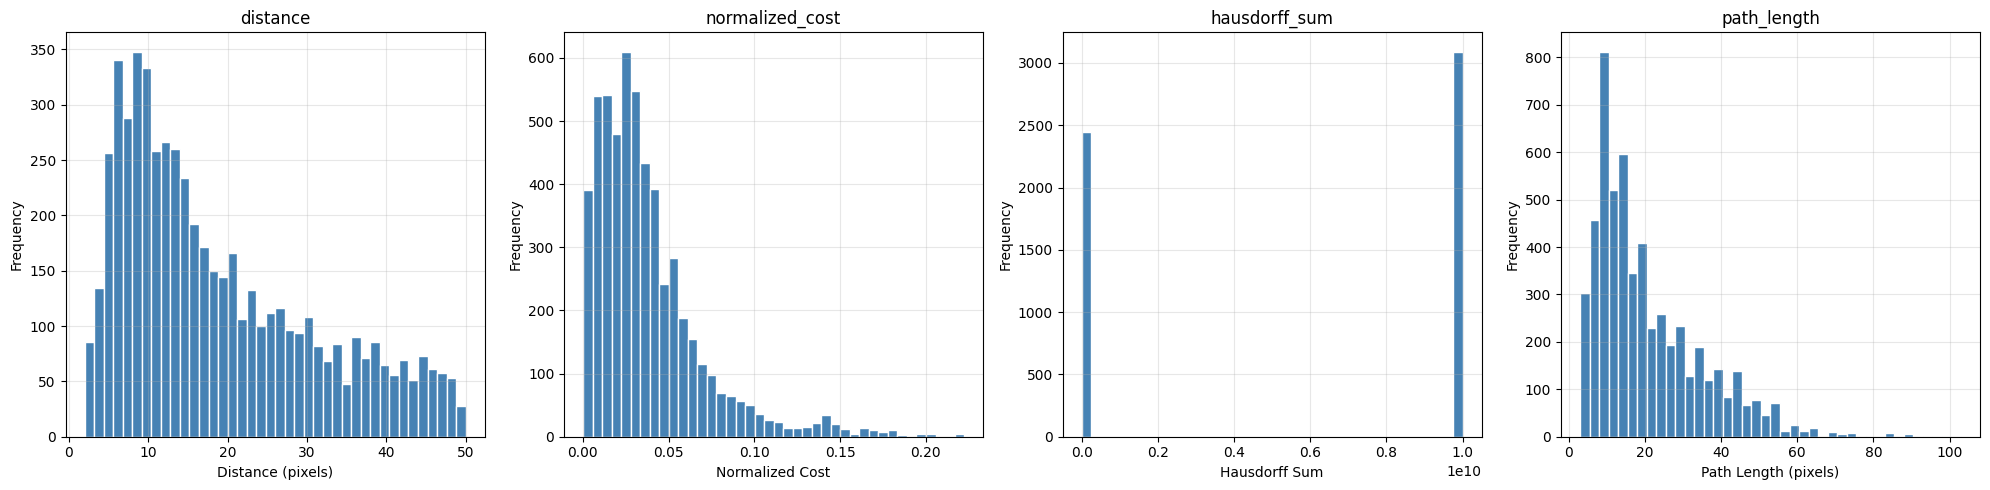

In [119]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, col, xlabel in zip(axes,
    ['distance', 'normalized_cost', 'hausdorff_sum', 'path_length'],
    ['Distance (pixels)', 'Normalized Cost', 'Hausdorff Sum', 'Path Length (pixels)']
):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.set_title(col)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

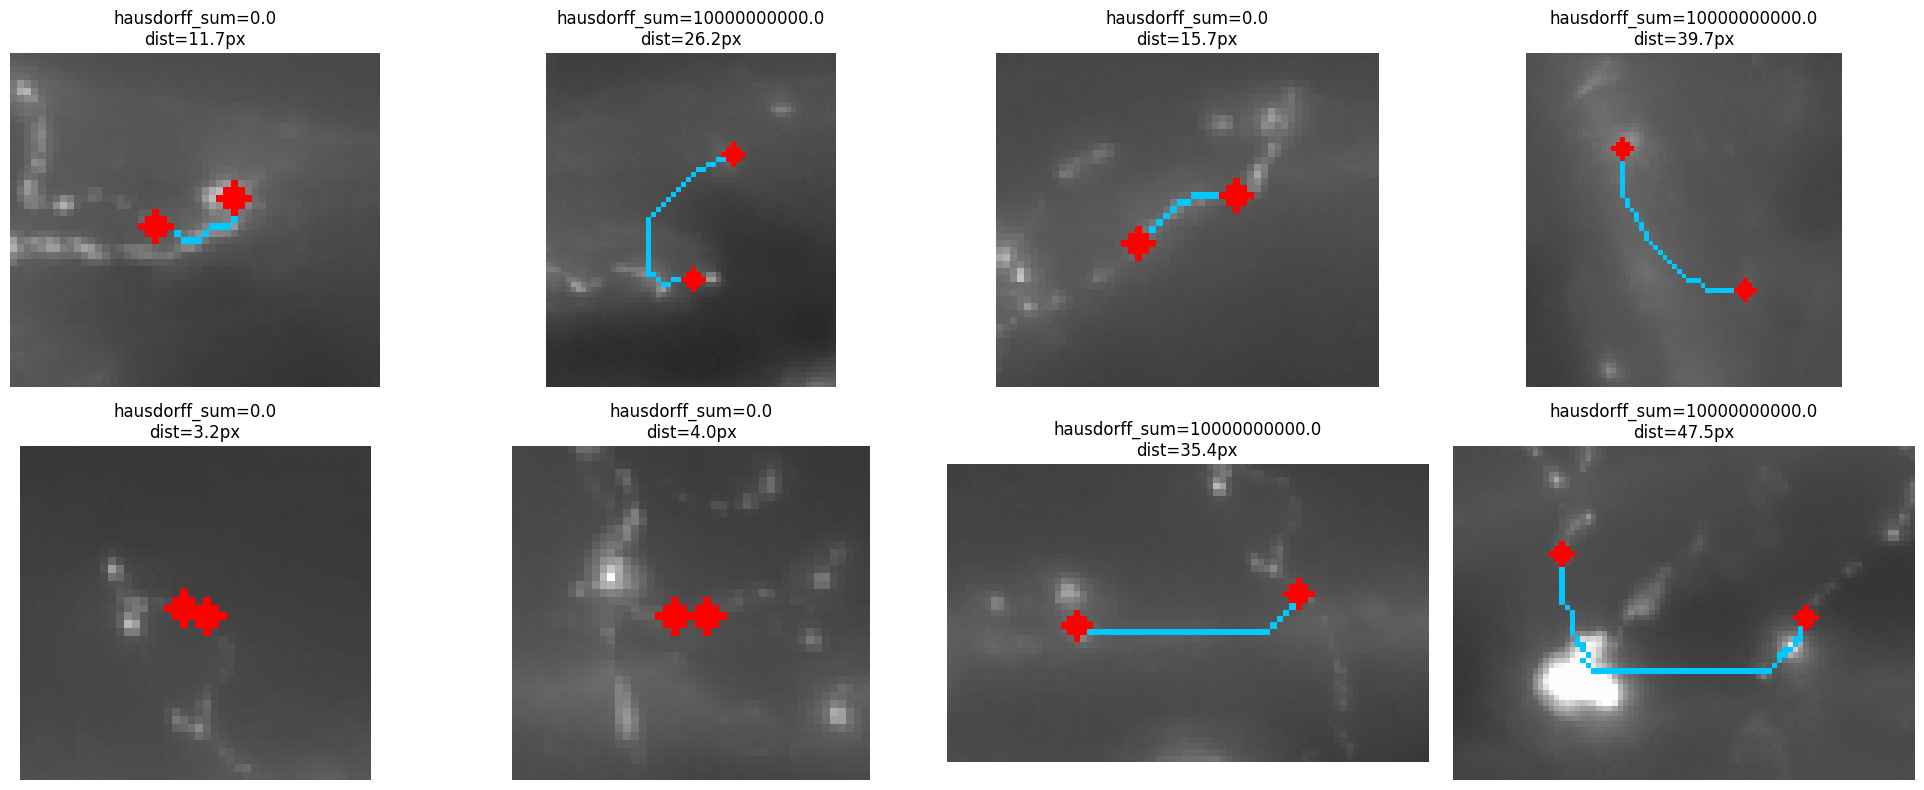

In [120]:
# Visualize random samples with their hausdorff_sum
num_examples = 8
sample_indices = np.random.choice(len(all_samples), min(num_examples, len(all_samples)), replace=False)

fig, axes = plt.subplots(2, num_examples // 2, figsize=(20, 8))
axes = axes.flatten()

for idx, sample_idx in enumerate(sample_indices):
    sample = all_samples[sample_idx]
    ax = axes[idx]
    
    path = sample['path']
    all_y = [p[0] for p in path] + [sample['seed1_y'], sample['seed2_y']]
    all_x = [p[1] for p in path] + [sample['seed1_x'], sample['seed2_x']]
    padding = 20
    min_y = max(0, min(all_y) - padding)
    max_y = min(orig_img.shape[0] - 1, max(all_y) + padding)
    min_x = max(0, min(all_x) - padding)
    max_x = min(orig_img.shape[1] - 1, max(all_x) + padding)
    
    roi = orig_img[min_y:max_y+1, min_x:max_x+1]
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)
    
    for p in path:
        local_y, local_x = p[0] - min_y, p[1] - min_x
        if 0 <= local_y < roi_rgb.shape[0] and 0 <= local_x < roi_rgb.shape[1]:
            roi_rgb[local_y, local_x] = [0, 200, 255]
    
    cv2.circle(roi_rgb, (sample['seed1_x'] - min_x, sample['seed1_y'] - min_y), 2, (255, 0, 0), -1)
    cv2.circle(roi_rgb, (sample['seed2_x'] - min_x, sample['seed2_y'] - min_y), 2, (255, 0, 0), -1)
    
    ax.imshow(roi_rgb)
    ax.set_title(f"hausdorff_sum={sample['hausdorff_sum']:.1f}\ndist={sample['distance']:.1f}px")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [121]:
# Visualize all paths colored by hausdorff_sum (green=low, red=high)
import matplotlib.cm as cm

hausdorff_arr = np.array([s['hausdorff_sum'] for s in all_samples])
h_min, h_max = hausdorff_arr.min(), hausdorff_arr.max()

viz = cv2.cvtColor(orig_img.copy(), cv2.COLOR_GRAY2BGR)

viz = cv2.addWeighted(viz, 0.7, cv2.cvtColor(label_img, cv2.COLOR_GRAY2BGR), 0.3, 0)

for u, v, data in seed_graph.edges(data=True):
    for y_i, x_i in data['path']:
        viz[y_i, x_i] = [0, 255, 0]


for sample in all_samples:
    if sample['hausdorff_sum'] > 1000:
        continue
    # t = np.exp(sample['hausdorff_sum'] - h_min) / (h_max - h_min + 1e-8)
    # color_rgb = cm.RdYlGn(1.0 - t)[:3]
    # color_bgr = [int(c * 255) for c in color_rgb[::-1]]
    for p in sample['path']:
        y, x = p
        if 0 <= y < viz.shape[0] and 0 <= x < viz.shape[1]:
            viz[y, x] = [255,0,0]

# plt.figure(figsize=(128, 128))
# plt.imshow(viz)
# plt.title(f'All paths colored by Hausdorff sum (green=low, red=high)\n'
#           f'range: {h_min:.1f} ~ {h_max:.1f}, total: {len(all_samples)} pairs')
# plt.axis('off')
# plt.tight_layout()
# plt.show()
cv2.imwrite(str(OUTPUT_DIR / f"dataset_{IMAGE_ID}_path_viz.png"), cv2.cvtColor(viz, cv2.COLOR_RGB2BGR))

True

In [122]:
print("="*60)
print("Dataset Statistics")
print("="*60)
print(f"\nTotal samples: {len(df)}")
print(f"\nFeature statistics:")
print(df[['distance', 'path_length', 'normalized_cost', 'hausdorff_sum']].describe())

Dataset Statistics

Total samples: 5534

Feature statistics:
          distance  path_length  normalized_cost  hausdorff_sum
count  5534.000000  5534.000000      5534.000000   5.534000e+03
mean     18.764564    20.458077         0.037843   5.585472e+09
std      12.221697    14.269639         0.031888   4.966053e+09
min       2.000000     3.000000         0.000215   0.000000e+00
25%       8.944272    10.000000         0.015929   0.000000e+00
50%      15.000000    16.000000         0.029748   1.000000e+10
75%      26.907248    28.000000         0.049668   1.000000e+10
max      50.000000   103.000000         0.222289   1.000000e+10
